In [ ]:




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TASK 1

In [35]:
accident = pd.read_excel("C:\\Users\\lavia\\Downloads\\QP_Data_road_accident_dataset_with_missing.xlsx")

In [36]:
accident.head(10)

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,NaN,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856980,22072.878500,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,NaN,9856.915064,Wet,Speeding,4,29164.412980,58009.145120,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212570,20907.151300,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293920,13584.060760,South America,3883.645634
5,India,2010,May,Monday,Evening,Urban,Street,Snowy,479.216834,2,...,4,8.205994,360.951795,Dry,Speeding,7,NaN,45995.605250,South America,3626.074027
6,China,2010,March,Monday,Afternoon,Rural,Street,Foggy,386.176217,3,...,3,17.851663,7607.804705,Wet,Weather,9,NaN,52342.431810,Asia,3408.182341
7,USA,2016,July,Friday,Afternoon,Rural,Main Road,Foggy,75.608688,3,...,2,46.740367,6061.407002,Dry,Speeding,8,4262.755621,70652.223520,South America,408.296453
8,Japan,2014,August,Thursday,Afternoon,Rural,Highway,Rainy,387.828675,3,...,2,NaN,3793.850542,Snow-covered,Mechanical Failure,5,37624.775980,13724.630950,Europe,2058.898279
9,USA,2007,April,Monday,Evening,Urban,Highway,Foggy,443.965408,3,...,3,NaN,1140.429308,Snow-covered,Distracted Driving,0,15801.190080,61948.862750,Australia,1840.206143


In [37]:
print("Rows and Columns :", accident.shape)

Rows and Columns : (132000, 30)


In [39]:
num_cols = accident.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Year', 'Visibility Level', 'Number of Vehicles Involved',
       'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue',
       'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries',
       'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume',
       'Insurance Claims', 'Medical Cost', 'Economic Loss',
       'Population Density'],
      dtype='object')


In [38]:
cat_cols = accident.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Country', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural',
       'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender',
       'Vehicle Condition', 'Accident Severity', 'Road Condition',
       'Accident Cause', 'Region'],
      dtype='object')


In [40]:
print(accident.dtypes)

Country                         object
Year                             int64
Month                           object
Day of Week                     object
Time of Day                     object
Urban/Rural                     object
Road Type                       object
Weather Conditions              object
Visibility Level               float64
Number of Vehicles Involved      int64
Speed Limit                      int64
Driver Age Group                object
Driver Gender                   object
Driver Alcohol Level           float64
Driver Fatigue                   int64
Vehicle Condition               object
Pedestrians Involved             int64
Cyclists Involved                int64
Accident Severity               object
Number of Injuries               int64
Number of Fatalities             int64
Emergency Response Time        float64
Traffic Volume                 float64
Road Condition                  object
Accident Cause                  object
Insurance Claims         

## Observation

All columns already have appropriate data types.
No mandatory type conversion is required.

# TASK 2A

In [41]:
#describe the numerical columns
num_cols = accident.select_dtypes(include=['int64','float64'])
num_cols.describe()

,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
count,132000.000000,125400.000000,132000.000000,132000.000000,104893.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,118824.000000,125400.000000,132000.000000,106979.000000,118800.000000,125400.000000
mean,2011.973348,275.104755,2.501227,74.544068,0.110463,0.500576,1.000773,0.998356,9.508205,1.995439,32.486666,5039.695672,4.495621,22999.326535,46028.388017,2505.985119
std,7.198624,129.946180,1.117272,26.001448,0.066818,0.500002,0.816304,0.817764,5.774366,1.412974,15.900793,2861.300571,2.867347,13309.840366,26642.146034,1441.036753
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110091,1000.335085,10.002669
25%,2006.000000,162.422604,2.000000,52.000000,0.053893,0.000000,0.000000,0.000000,5.000000,1.000000,18.694200,2554.836546,2.000000,11594.699610,23253.528405,1257.505421
50%,2012.000000,274.808977,3.000000,74.000000,0.107667,1.000000,1.000000,1.000000,9.000000,2.000000,32.549514,5033.213155,4.000000,22687.634120,45484.381415,2504.196516
75%,2018.000000,388.070736,3.000000,97.000000,0.161436,1.000000,2.000000,2.000000,15.000000,3.000000,46.288919,7523.931508,7.000000,33869.677745,67731.981662,3757.099191
max,2024.000000,499.999646,4.000000,119.000000,0.249989,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622970,4999.991745


In [42]:
accident.describe().loc['std'].sort_values(ascending=False)

Economic Loss                  26642.146034
Medical Cost                   13309.840366
Traffic Volume                  2861.300571
Population Density              1441.036753
Visibility Level                 129.946180
Speed Limit                       26.001448
Emergency Response Time           15.900793
Year                               7.198624
Number of Injuries                 5.774366
Insurance Claims                   2.867347
Number of Fatalities               1.412974
Number of Vehicles Involved        1.117272
Cyclists Involved                  0.817764
Pedestrians Involved               0.816304
Driver Fatigue                     0.500002
Driver Alcohol Level               0.066818
Name: std, dtype: float64

- Economic Loss shows the highest variation because it has the largest standard deviation.

# TASK 2B

In [43]:
mean_medical = accident['Medical Cost'].mean()
print("Mean =", mean_medical)

Mean = 22999.326534801297


In [44]:
median_medical = accident['Medical Cost'].median()
print("Median =", median_medical)

Median = 22687.63412


- Since:
Mean > Median (22999.33 > 22687.63), the distribution is positively skewed (right-skewed).

# TASK 3A

In [45]:
#Missing Values in Each Column
accident.isnull().sum()

Country                            0
Year                               0
Month                              0
Day of Week                        0
Time of Day                        0
Urban/Rural                        0
Road Type                          0
Weather Conditions                 0
Visibility Level                6600
Number of Vehicles Involved        0
Speed Limit                        0
Driver Age Group                   0
Driver Gender                      0
Driver Alcohol Level           27107
Driver Fatigue                     0
Vehicle Condition                  0
Pedestrians Involved               0
Cyclists Involved                  0
Accident Severity                  0
Number of Injuries                 0
Number of Fatalities               0
Emergency Response Time        13176
Traffic Volume                  6600
Road Condition                     0
Accident Cause                     0
Insurance Claims                   0
Medical Cost                   25021
E

In [46]:
#Columns Having Missing Values
missing = accident.isnull().sum()
missing = missing[missing > 0]
print(missing)

Visibility Level            6600
Driver Alcohol Level       27107
Emergency Response Time    13176
Traffic Volume              6600
Medical Cost               25021
Economic Loss              13200
Population Density          6600
dtype: int64


In [47]:
#Percentage of Missing Values
missing_percent = (accident.isnull().sum()/len(accident))*100
missing_percent = missing_percent[missing_percent>0]
print(missing_percent)

Visibility Level            5.000000
Driver Alcohol Level       20.535606
Emergency Response Time     9.981818
Traffic Volume              5.000000
Medical Cost               18.955303
Economic Loss              10.000000
Population Density          5.000000
dtype: float64


In [48]:
missing_table = pd.DataFrame({
    'Missing Values': accident.isnull().sum(),
    'Percentage': (accident.isnull().sum()/len(accident))*100
})

missing_table = missing_table[missing_table['Missing Values']>0]

print(missing_table)

                         Missing Values  Percentage
Visibility Level                   6600    5.000000
Driver Alcohol Level              27107   20.535606
Emergency Response Time           13176    9.981818
Traffic Volume                     6600    5.000000
Medical Cost                      25021   18.955303
Economic Loss                     13200   10.000000
Population Density                 6600    5.000000


- The dataset contains missing values in seven variables. The highest missing percentage is observed in Driver Alcohol Level (20.54%), followed by Medical Cost (18.96%) and Economic Loss (10%). 

# TASK 3B
b. Explain and identify which missing value technique can be used for variables Visibility Level, Traffic Volume, and Population Density.

In [49]:
#Visibility Level
accident['Visibility Level'] = accident['Visibility Level'].fillna(
    accident['Visibility Level'].median()
)

Technique Used: Median Imputation

- It is a numerical variable.
- Missing percentage is only 5%.
- Visibility can vary greatly due to weather conditions.
- Median is robust to outliers.

In [50]:
#Traffic Volume
accident['Traffic Volume'] = accident['Traffic Volume'].fillna(
    accident['Traffic Volume'].median()
)

Technique Used: Median Imputation

- Numerical variable.
- Missing percentage is 5%.
- Traffic Volume usually has peak-hour outliers.
- Median is preferred over mean.

In [51]:
#Population Density
accident['Population Density'] = accident['Population Density'].fillna(
    accident['Population Density'].median()
)

Technique Used: Median Imputation

Numerical variable.
Missing percentage is 5%.
Urban regions have very high densities compared to rural regions.
Median is less affected by extreme values.

# TASK 3C
Explain and identify which missing value technique can be used for variables Driver Alcohol Level, Emergency Response Time, and Medical Cost.

In [52]:
#Driver Alcohol Level
accident['Driver Alcohol Level'] = accident['Driver Alcohol Level'].fillna(
    accident['Driver Alcohol Level'].median()
)

Median Imputation

Alcohol levels are often right-skewed.
Some drivers may have very high alcohol concentrations.
Median is not affected by these extreme values.

In [53]:
#Emergency Response Time
accident['Emergency Response Time'] = accident['Emergency Response Time'].fillna(
    accident['Emergency Response Time'].median()
)

Median Imputation

Emergency response times can have unusually high delays.
Median is more robust than mean.

In [54]:
#Medical Cost
accident['Medical Cost'] = accident['Medical Cost'].fillna(
    accident['Medical Cost'].median()
)

Median Imputation

Medical Cost is positively skewed, so Median Imputation is preferred.

# TASK 3D
How can missingness in Driver Alcohol Level be both MAR and MNAR? Explain with reference to the dataset.

- MAR (Missing At Random)

If missing alcohol values depend on another observed variable, such as Accident Severity, then:

Drivers involved in severe accidents may not undergo alcohol testing due to emergency treatment. Hence, missingness depends on Accident Severity and is classified as MAR.

- MNAR (Missing Not At Random)

If missing alcohol values depend on the alcohol level itself:

Drivers with very high alcohol levels may refuse testing or provide incomplete information. In this case, missingness depends on the missing alcohol value itself and is classified as MNAR.

# TASK 4A
Plot a chart showing accidents by Weather Condition, Road Type and Accident Severity.

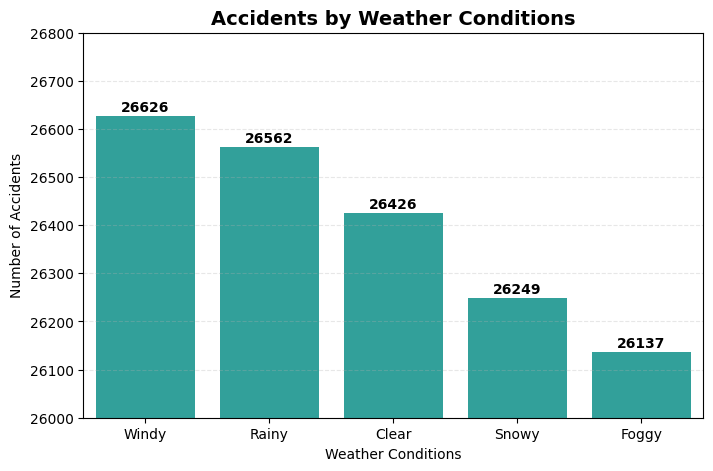

In [62]:
#Accidents by Weather Condition

weather_count = accident['Weather Conditions'].value_counts()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=weather_count.index,
    y=weather_count.values,
    color='#20B2AA'
)

for i, v in enumerate(weather_count.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(26000,26800)
plt.title(
    "Accidents by Weather Conditions",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Weather Conditions")
plt.ylabel("Number of Accidents")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Conclusion 
- Windy weather records the highest number of accidents, followed by Rainy and Clear conditions. Foggy weather has the lowest number of accidents. The differences among categories are relatively small, indicating that accidents occur under all weather conditions and are not dominated by a single weather type in this dataset.

### Bar Chart

Because:

Weather Conditions is a categorical variable.
We want to compare the number of accidents in each weather category.
Bar charts are the best choice for comparing frequencies across categories.

In [63]:
#Accidents by Road Type
road_count = accident['Road Type'].value_counts()
print(road_count)

Road Type
Main Road    44197
Highway      43920
Street       43883
Name: count, dtype: int64


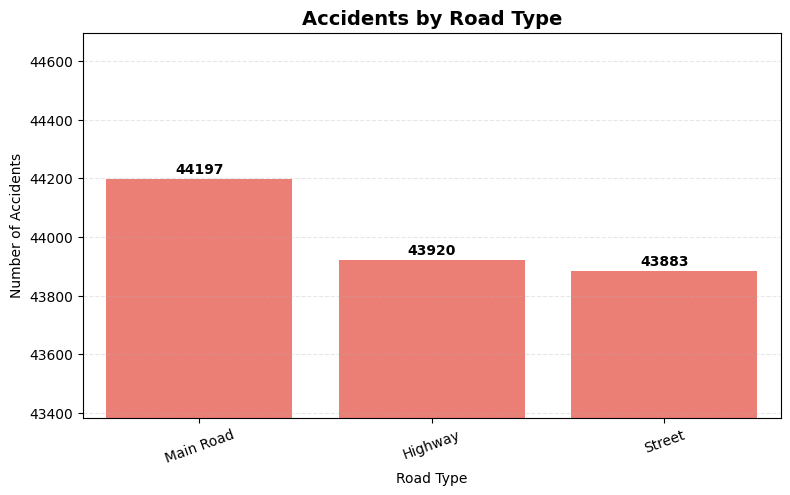

In [ ]:
road_count = accident['Road Type'].value_counts()

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=road_count.index,
    y=road_count.values,
    color='#FF6F61'  
)

# Add count labels
for i, v in enumerate(road_count.values):
    ax.text(
        i,
        v + 20,
        str(v),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(road_count.min()-500, road_count.max()+500)

plt.title(
    "Accidents by Road Type",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Road Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Bar Chart because:

Road Type is a categorical variable.
We want to compare the number of accidents across categories such as:
Highway
Rural Road
City Road
Expressway, etc.
Bar charts are the best choice for comparing frequencies among categories.

### Conclusion
Main Road has the highest number of accidents (44,197), followed by Highway (43,920) and Street (43,883). The difference among road types is small, indicating that accidents occur frequently across all road categories in this dataset.

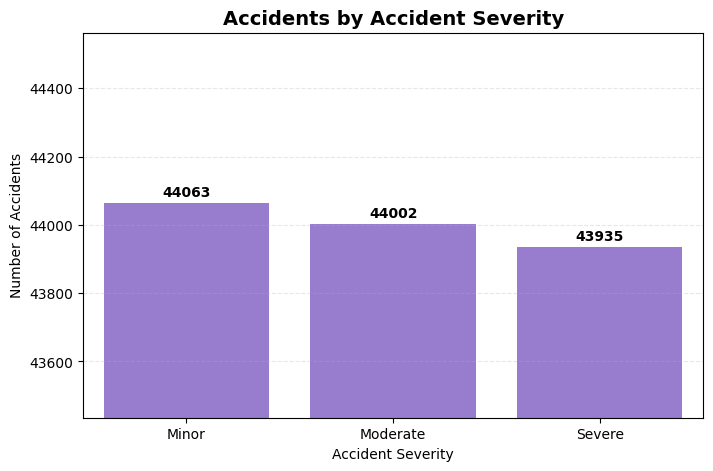

Accident Severity
Minor       44063
Moderate    44002
Severe      43935
Name: count, dtype: int64


In [65]:
#Accidents by Accident Severity
severity_count = accident['Accident Severity'].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=severity_count.index,
    y=severity_count.values,
    color='#9370DB'  
)

for i, v in enumerate(severity_count.values):
    ax.text(
        i,
        v + 20,
        str(v),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(severity_count.min()-500, severity_count.max()+500)
plt.title(
    "Accidents by Accident Severity",
    fontsize=14,
    fontweight='bold'
)
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
print(severity_count)

Bar Chart

Accident Severity is a categorical variable.
We want to compare accident frequencies among categories like:
Minor
Moderate
Severe
Fatal

A bar chart is the best choice for comparing counts across categories.

### Conclusion
Minor accidents are the most frequent (44,063 cases), followed closely by Moderate accidents (44,002). Severe accidents (43,935) occur slightly less frequently. Overall, the accident severity categories are nearly evenly distributed in this dataset.

# TASK 4B
Plot a boxplot for Economic Loss, Medical Cost grouped By Accident Severity.

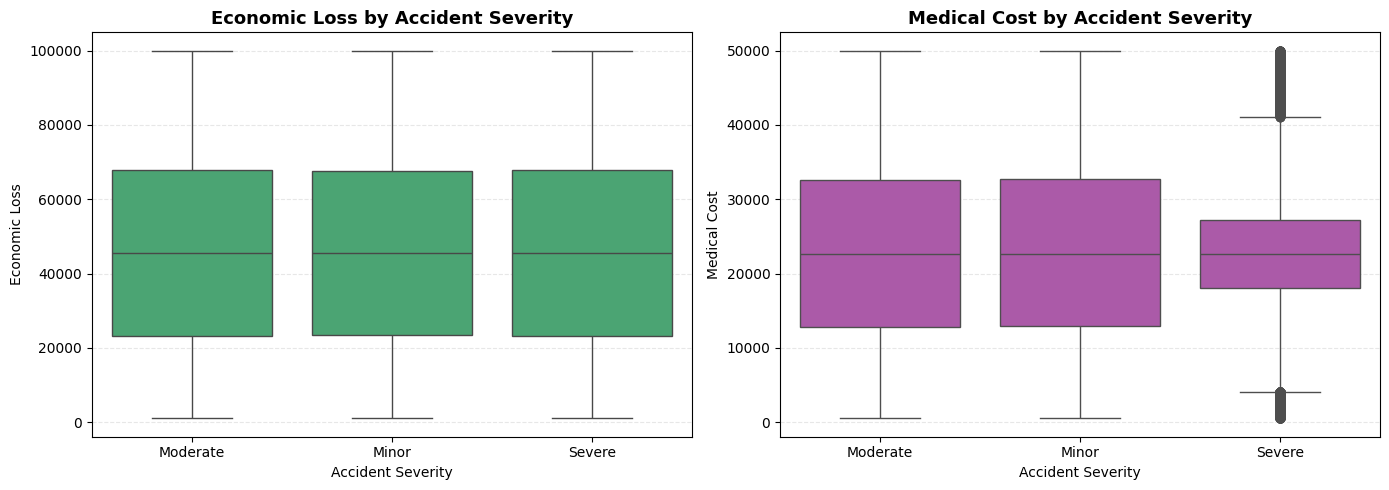

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    data=accident,
    x='Accident Severity',
    y='Economic Loss',
    color='#3CB371',
    ax=axes[0]
)

axes[0].set_title(
    "Economic Loss by Accident Severity",
    fontsize=13,
    fontweight='bold'
)

axes[0].grid(axis='y', linestyle='--', alpha=0.3)

sns.boxplot(
    data=accident,
    x='Accident Severity',
    y='Medical Cost',
    color="#B84DB4",
    ax=axes[1]
)

axes[1].set_title(
    "Medical Cost by Accident Severity",
    fontsize=13,
    fontweight='bold'
)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- Economic Loss by Accident Severity

The median Economic Loss is almost the same for Moderate, Minor, and Severe accidents. The spread of values is also similar across all severity categories, indicating that Economic Loss is fairly evenly distributed in this dataset and does not vary significantly with Accident Severity.

- Medical Cost by Accident Severity

The median Medical Cost is similar across all accident severity levels. However, the Severe category shows several outliers, indicating that some severe accidents incur exceptionally high medical expenses compared to the majority of cases.

Boxplot because:

Accident Severity is a categorical variable.
Economic Loss is a numerical variable.
A Boxplot helps visualize:
Median
Interquartile Range (IQR)
Spread of data
Outliers

This makes it easy to compare how economic losses vary across accident severity categories.

# TASK 4C

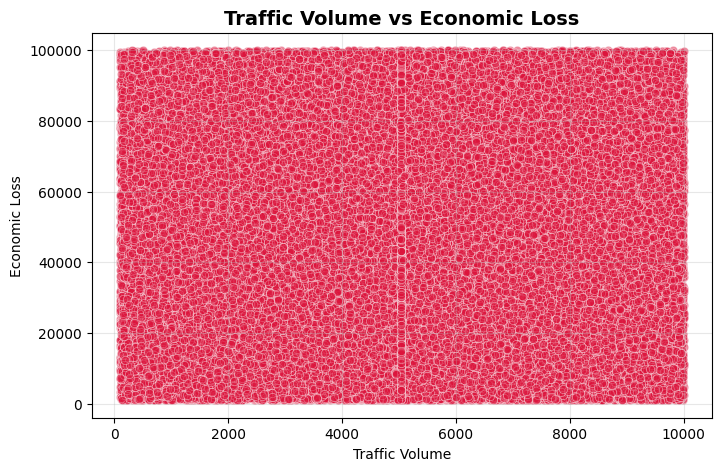

In [ ]:
#1. Traffic Volume vs Economic Loss
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=accident,
    x='Traffic Volume',
    y='Economic Loss',
    color='#DC143C',
    alpha=0.5
)

plt.title(
    "Traffic Volume vs Economic Loss",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Traffic Volume")
plt.ylabel("Economic Loss")

plt.grid(alpha=0.3)

plt.show()

The scatter plot does not show a clear positive or negative relationship between Traffic Volume and Economic Loss. The points are spread uniformly across the graph, indicating a very weak or no correlation between these two variables in the dataset. Economic Loss varies widely regardless of the traffic volume.

C:\Users\lavia\AppData\Local\Temp\ipykernel_22744\2699530475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


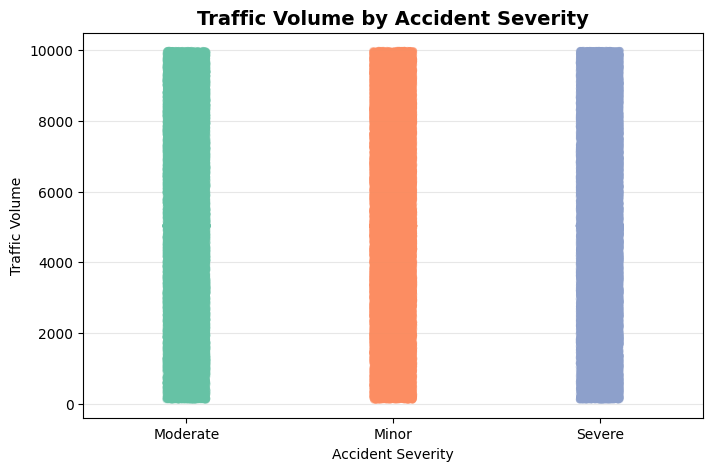

In [69]:
#Traffic Volume vs Accident Severity
plt.figure(figsize=(8,5))

sns.stripplot(
    data=accident,
    x='Accident Severity',
    y='Traffic Volume',
    palette='Set2',
    alpha=0.3
)

plt.title(
    "Traffic Volume by Accident Severity",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='y', alpha=0.3)

plt.show()

Traffic Volume is distributed similarly across Minor, Moderate, and Severe accidents. No severity category is associated with a distinct range of traffic volumes, suggesting that accidents of different severity levels occur under varying traffic conditions.

# TASK 4D

Interpretation 1: Weather Conditions

Accidents are almost equally distributed across all weather conditions. Windy weather records the highest number of accidents, while Foggy weather records the lowest. This suggests that accidents occur under all weather conditions and are not concentrated in one specific weather type.

Interpretation 2: Road Type

Main Roads experience the highest number of accidents, followed by Highways and Streets. However, the difference is small, indicating that accidents occur frequently across all road types in the dataset.

Interpretation 3: Medical Cost by Accident Severity

Medical Costs show a similar median across accident severity categories. However, the Severe category contains several outliers, indicating that some severe accidents result in exceptionally high medical expenses.

# TASK 5


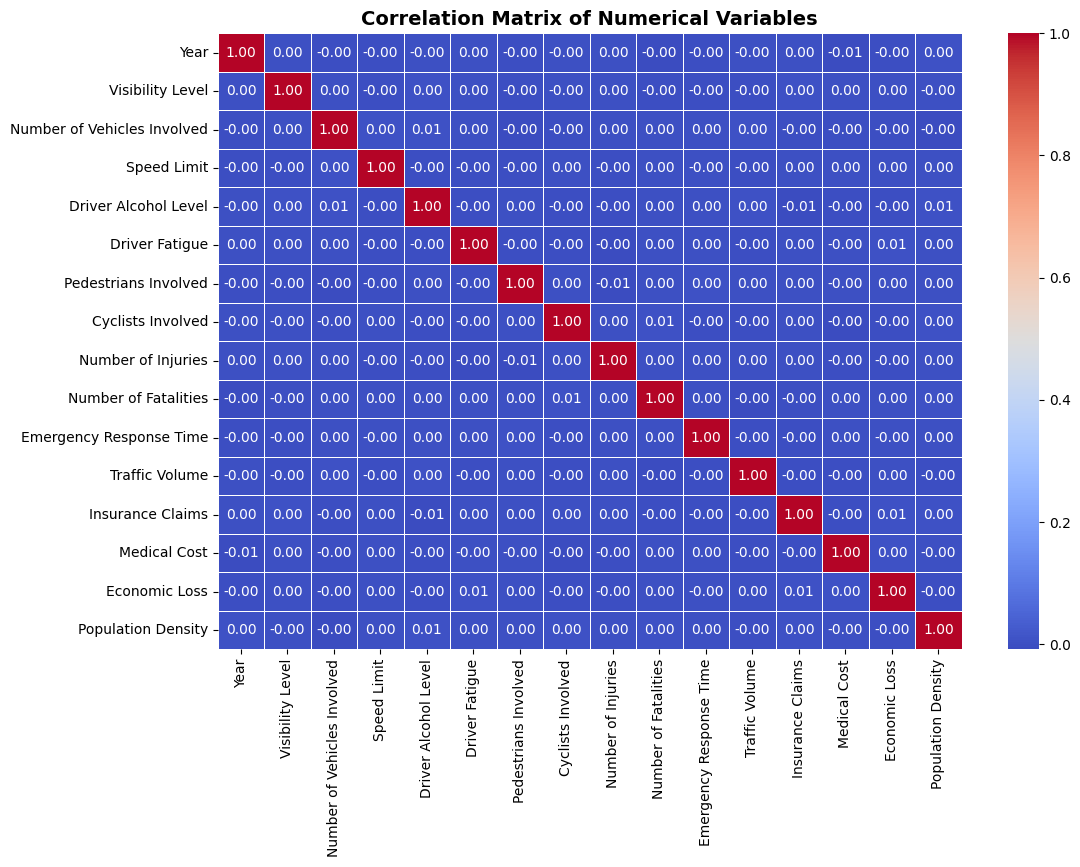

In [70]:

corr = accident.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=14,
    fontweight='bold'
)

plt.show()

The correlation matrix helps identify relationships among numerical variables. Positive correlations indicate variables increasing together, while negative correlations indicate inverse relationships. Categorical variables cannot be directly included in correlation analysis because correlation requires numerical and meaningful ordered values.

# TASK 6

In [71]:
cols = [
    'Medical Cost',
    'Economic Loss',
    'Traffic Volume',
    'Emergency Response Time'
]

for col in cols:

    Q1 = accident[col].quantile(0.25)
    Q3 = accident[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = accident[
        (accident[col] < lower) |
        (accident[col] > upper)
    ]

    print(col)
    print("Outliers :", len(outliers))
    print()

Medical Cost
Outliers : 0

Economic Loss
Outliers : 0

Traffic Volume
Outliers : 0

Emergency Response Time
Outliers : 0



Task 6(b): Observation

High Medical Cost values are not necessarily errors. They may represent severe accidents requiring expensive treatments, surgeries, or prolonged hospitalization. Therefore, these extreme values are meaningful observations rather than data entry mistakes.